In [3]:
import seaborn as sns
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from adjustText import adjust_text

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

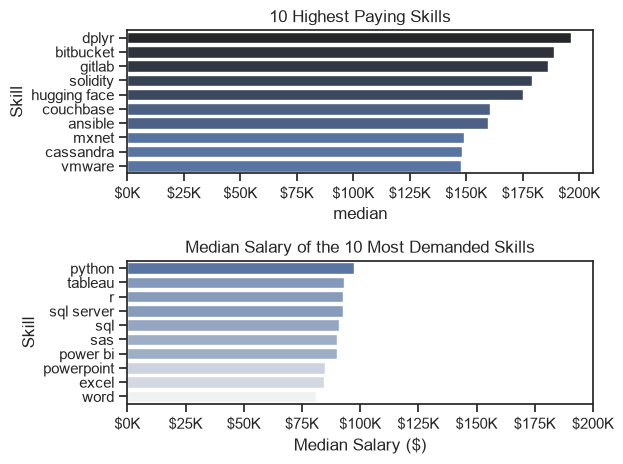

In [ ]:
df_DA = df[(df['job_country'] == 'United States') &  (df['job_title_short'] == 'Data Analyst')].copy()
df_DA = df_DA.dropna(subset = ['salary_year_avg'])
df_DA = df_DA.explode('job_skills')
df_DA[['salary_year_avg', 'job_skills']] 

grouped_m= df_DA.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by = 'median', ascending = False)
grouped_c= df_DA.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by = 'count', ascending = False)


grouped_m = grouped_m.head(10).sort_values(by = 'median', ascending = False)
grouped_c =grouped_c.head(10).sort_values(by = 'median', ascending = False)

fig, ax = plt.subplots(2, 1)
sns.set_theme(style = 'ticks')

sns.barplot(data = grouped_m, x='median', y=grouped_m.index, ax=ax[0], hue= 'median',  palette='dark:b_r', legend=False)

ax[0].set_title('10 Highest Paying Skills')

ax[0].set_ylabel('Skill')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))


sns.barplot(data = grouped_c, x= 'median', y=grouped_c.index, ax=ax[1], hue='median', palette='light:b', legend=False)

ax[1].set_title('Median Salary of the 10 Most Demanded Skills')
ax[1].set_xlabel('Median Salary ($)')
ax[1].set_ylabel('Skill')
ax[1].set_xlim(0, 200000)
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.tight_layout()
plt.show()